In [ ]:
# SECTION A - Concept Application

In [ ]:
# Question 1 
Since the dataset contains 50,000 records and 14% of the delivery_time_mins values are missing, 
I would not drop the rows. Removing 14% of the data would eliminate about 7,000 records, 
which is a significant amount of information and could introduce bias into the analysis. Instead, I would use imputation.
The choice between mean and median depends on the distribution (skewness) of the delivery_time_mins column

(df['delivery_time_mins'].isnull().sum() / len(df)) * 100
df['delivery_time_mins'].skew()
# if data is skewed then use this 
df['delivery_time_mins'] = df['delivery_time_mins'].fillna(median()[0])

# Before performing any analysis, convert the customer_rating column from string (object) to a numeric (float) data type.
df['customer_rating'].dtype()
# Convert the column to numeric
df['customer_rating'] = pd.to_numeric(df['customer_rating'])
# Verify the new data type
df['customer_rating'].dtype()

In [63]:
# Question 2
# NumPy uses boolean indexing and statistical functions to efficiently identify surge days without writing a Python for loop. 
# Statistical functions such as np.mean() and np.std() first calculate the average and standard deviation of the entire array. 
# These values are then used to define a threshold for identifying surge days.

# For example, suppose a surge day is defined as any day where the number of orders is greater than:

import numpy as np

orders = np.array([120, 150, 180, 300, 140, 220])

threshold = np.mean(orders) + np.std(orders)

mask = orders > threshold

surge_days = orders[mask]

print(mask)
# [False False False  True False  True]

print(surge_days)
# [300 220]

[False False False  True False False]
[300]


In [ ]:
# Question 3
# (a) Is delivery time correlated with customer rating?

# This is a bivariate analysis because it examines the relationship between two numerical variables:

# delivery_time_mins
# customer_rating
sns.scatterplot(data=df, x='delivery_time_mins', y='customer_rating')
# A scatter plot displays each observation as a point, making it easy to identify correlation, trends, clusters,
# and outliers between the two numeric variables. It helps determine whether customer ratings increase, decrease, 
# or remain unchanged as delivery time changes.

# (b) How is average order value distributed across restaurant categories?
# This is a bivariate analysis because it compares:
# One categorical variable: restaurant_category
# One numerical variable: average_order_value
sns.boxplot(data=df, x='restaurant_category', y='average_order_value')
# A box plot clearly shows the median, interquartile range (IQR), spread, and outliers of average order values for each restaurant category.
# It makes it easy to compare the distribution of order values across multiple categories.

In [ ]:
# Question 4
# To generate a report showing every restaurant's name and total revenue, including restaurants that have not yet received any orders, 
# the appropriate SQL join is a LEFT JOIN.

# A LEFT JOIN returns all rows from the restaurants table (the left table) and the matching rows from the orders table. 
# If a restaurant has no matching orders, the columns from the orders table are returned as NULL. 
# This ensures that restaurants with zero orders are still included in the report.

SELECT
    r.name,
    COALESCE(SUM(o.order_value), 0) AS total_revenue
FROM restaurants r
LEFT JOIN orders o
ON r.restaurant_id = o.restaurant_id
GROUP BY r.restaurant_id, r.name;

In [ ]:
# Question 5
# The RANK() function assigns a rank to each delivery agent based on the number of completed deliveries in descending order. 
# Using PARTITION BY city ensures that ranking starts from 1 separately for each city.

RANK() OVER (
    PARTITION BY city
    ORDER BY completed_deliveries DESC
) AS agent_rank

# Retrieving the Previous Agent's Delivery Count

# The LAG() function returns the value from the previous row within the same partition. It allows each agent's completed 
# deliveries to be compared with the agent ranked directly above them.

LAG(completed_deliveries) OVER (
    PARTITION BY city
    ORDER BY completed_deliveries DESC
) AS previous_agent_deliveries



In [ ]:
# Question 6
# A CTE separates the query into logical blocks, making it easier to read and understand. 
# The intermediate result (top 5 categories) is defined once and then referenced in the main query.

# Advantages:
# Better readability: The query is divided into clear, sequential steps.
# Reusability: The CTE can be referenced multiple times within the same query without rewriting the logic.
# Easier debugging: Each CTE can be executed independently to verify that it produces the expected result before combining it with the final query.

# Conclusion: For the given two-step reporting requirement, a CTE is the preferred solution because it improves readability, 
# allows reuse of the intermediate result, and simplifies debugging and maintenance. A nested subquery is more appropriate only for straightforward, 
# one-time filtering operations where the logic is simple and the intermediate result does not need to be reused.

In [ ]:
# Secion B -Practical Coding Task
# TASK 1

In [3]:
import numpy as np

In [216]:
np.random.seed(42)
daily_orders =np.random.randint(100,801,30)
daily_revenue =np.random.randint(5000,50000,30)

total_orders = np.sum(daily_orders)
total_revenue= np.random.uniform(5000,50000,30)

mean_orders = np.mean(daily_orders)
std_orders = np.std(daily_orders)

highest_revenue_day = np.argmax(daily_revenue)


print("Total Orders:",total_orders)
print("Total Revenue:",total_revenue)
print("Mean Daily orders:",round (mean_orders,2))
print("Standared Deviation of Daily Orders:",round(std_orders,2))
print("Day With Highest Revenue(0 based Index):",highest_revenue_day)
print("Highest Revenue: ₹{:.2f}".format(daily_revenue[highest_revenue_day]))


# Boolean Indexing for peak orders
threshold = mean_orders + std_orders
peak_days = daily_orders > threshold

print("\nThreshold (Mean + Std Dev):", round(threshold, 2))
print("Number of Peak Days:",np.sum(peak_days))
print("Peak Days Indicies:",np.where(peak_days)[0])
print("orders on peak Days:",daily_orders[peak_days])
print("Total Revenue on Peak Days: ₹{:.2f}".format(np.sum(daily_revenue[peak_days])))

orders_matrix=daily_orders.reshape(5,6)
print("\nOrders Matrix (5×6):")
print(orders_matrix)

# Weekly totals
weekly_totals = np.sum(orders_matrix, axis=1)

print("\nTotal Orders for Each Weekly Block:")
for i, total in enumerate(weekly_totals, start=1):
    print(f"Week {i}: {total}")

Total Orders: 12279
Total Revenue: [10491.72056802 27282.96095501  6547.48345018 45919.41809355
 16645.099172   34813.50279593 19026.99842402 28403.060953
 29601.96257045 13318.45049865 48631.30824941 39880.97705125
 47277.45237039 45267.23076924 31905.4990465  46484.34057604
  8982.16259234 13819.22880886  7035.22800097 19639.86488435
 22490.47803603 17210.70642983 42293.18791184 21053.89970121
 17642.05293593 29421.32374212 11341.59012386 41098.86413393
  8354.77896559 49409.91214702]
Mean Daily orders: 409.3
Standared Deviation of Daily Orders: 195.9
Day With Highest Revenue(0 based Index): 22
Highest Revenue: ₹48323.00

Threshold (Mean + Std Dev): 605.2
Number of Peak Days: 4
Peak Days Indicies: [ 5  7 16 18]
orders on peak Days: [800 714 763 761]
Total Revenue on Peak Days: ₹94728.00

Orders Matrix (5×6):
[[202 535 370 206 171 800]
 [120 714 221 566 314 430]
 [558 187 472 199 763 230]
 [761 408 443 591 513 485]
 [291 376 260 559 413 121]]

Total Orders for Each Weekly Block:
Week 

In [218]:
# TASK 2

In [230]:
import numpy as np
import pandas as pd

In [248]:
data = {
    "order_id": [101,102,103,104,105,106,107,108,109,110,111,
              112,113,114,115,116,117,118,119,120],
    
    "customer_name": ["Amit","Priya","Rahul","Sneha","Karan",
                      "Neha","Rohit","Pooja","Arjun","Simran",
                      "Vikas","Meera","Ankit","Riya","Dev",
                      "Nisha","Jay","Isha","Manav","Krisha"],
    "restaurant_name": ["Dominos","KFC","McDonalds","Pizza Hut","Subway",
                        "Burger King","Dominos","KFC","Subway","McDonalds",
                        "Pizza Hut","Burger King","Dominos","KFC","Subway",
                        "Pizza Hut","Burger King","Dominos","McDonalds","KFC"],

    "category": ["Pizza","Fast Food","Burger","Pizza","Sandwich",
                 np.nan,"Pizza","Fast Food","Sandwich","Burger",
                 "Pizza","Fast Food",np.nan,"Fast Food","Sandwich",
                 "Pizza","Fast Food","Pizza","Burger",np.nan],

    "delivery_time_mins": [30,45,np.nan,35,28,
                           50,32,40,np.nan,36,
                           38,41,29,33,27,
                           np.nan,42,31,37,39],

    "order_value": [450,320,550,600,280,
                    4500,510,430,np.nan,620,
                    580,390,450,np.nan,310,
                    470,520,490,610,np.nan],

    "rating": [4.5,4.0,np.nan,3.8,4.7,
               4.2,4.8,np.nan,3.9,4.4,
               4.1,4.3,4.9,4.0,np.nan,
               4.6,4.2,4.5,3.7,4.8]
}
df =pd.DataFrame(data)

df = pd.concat([df,df.iloc[[2,5,10]]],ignore_index=True)


In [260]:
print("NUll Values Before fill:")
print(df.isnull().sum())

NUll Values Before fill:
order_id              0
customer_name         0
restaurant_name       0
category              3
delivery_time_mins    3
order_value           3
rating                3
dtype: int64


In [254]:
df.shape

(23, 7)

In [258]:
df = df.drop_duplicates()
df

,order_id,customer_name,restaurant_name,category,delivery_time_mins,order_value,rating
0,101,Amit,Dominos,Pizza,30.0,450.0,4.5
1,102,Priya,KFC,Fast Food,45.0,320.0,4.0
2,103,Rahul,McDonalds,Burger,NaN,550.0,NaN
3,104,Sneha,Pizza Hut,Pizza,35.0,600.0,3.8
4,105,Karan,Subway,Sandwich,28.0,280.0,4.7
5,106,Neha,Burger King,NaN,50.0,4500.0,4.2
6,107,Rohit,Dominos,Pizza,32.0,510.0,4.8
7,108,Pooja,KFC,Fast Food,40.0,430.0,NaN
8,109,Arjun,Subway,Sandwich,NaN,NaN,3.9
9,110,Simran,McDonalds,Burger,36.0,620.0,4.4


In [262]:
df.shape

(20, 7)

In [268]:
Q1 = df["order_value"].quantile(0.25)
Q3 = df["order_value"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [274]:

print(lower_bound)
print(upper_bound)

205.0
805.0


In [280]:
outliers = df[(df['order_value']<lower_bound) |
(df['order_value']> upper_bound)]

In [288]:
outliers.head(5)

,order_id,customer_name,restaurant_name,category,delivery_time_mins,order_value,rating
5,106,Neha,Burger King,NaN,50.0,4500.0,4.2


In [290]:
df["order_value"] = df["order_value"].clip(
    lower=lower_bound,
    upper=upper_bound
)

In [292]:
df['order_value']

0     450.0
1     320.0
2     550.0
3     600.0
4     280.0
5     805.0
6     510.0
7     430.0
8       NaN
9     620.0
10    580.0
11    390.0
12    450.0
13      NaN
14    310.0
15    470.0
16    520.0
17    490.0
18    610.0
19      NaN
Name: order_value, dtype: float64

In [294]:
print(df["order_value"].describe())

count     17.000000
mean     493.235294
std      131.825419
min      280.000000
25%      430.000000
50%      490.000000
75%      580.000000
max      805.000000
Name: order_value, dtype: float64


In [ ]:
# TASK 3



In [297]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [301]:
df = pd.DataFrame({
    "order_id": range(101, 121),
    "customer_name": [
        "Amit","Priya","Rahul","Sneha","Karan",
        "Neha","Rohit","Pooja","Arjun","Simran",
        "Vikas","Meera","Ankit","Riya","Dev",
        "Nisha","Jay","Isha","Manav","Krisha"
    ],
    "restaurant_name": np.random.choice(
        ["Dominos", "KFC", "McDonalds", "Pizza Hut", "Subway"],
        20
    ),
    "category": np.random.choice(
        ["Pizza", "Burger", "Fast Food", "Sandwich"],
        20
    ),
    "delivery_time_mins": np.random.randint(20, 60, 20),
    "order_value": np.random.randint(200, 1200, 20),
    "rating": np.round(np.random.uniform(3.5, 5.0, 20), 1)
})
df.head(5)

,order_id,customer_name,restaurant_name,category,delivery_time_mins,order_value,rating
0,101,Amit,Dominos,Pizza,22,614,3.9
1,102,Priya,Subway,Fast Food,39,1189,4.6
2,103,Rahul,Dominos,Burger,55,497,4.8
3,104,Sneha,Dominos,Sandwich,38,810,4.8
4,105,Karan,McDonalds,Pizza,45,462,4.1


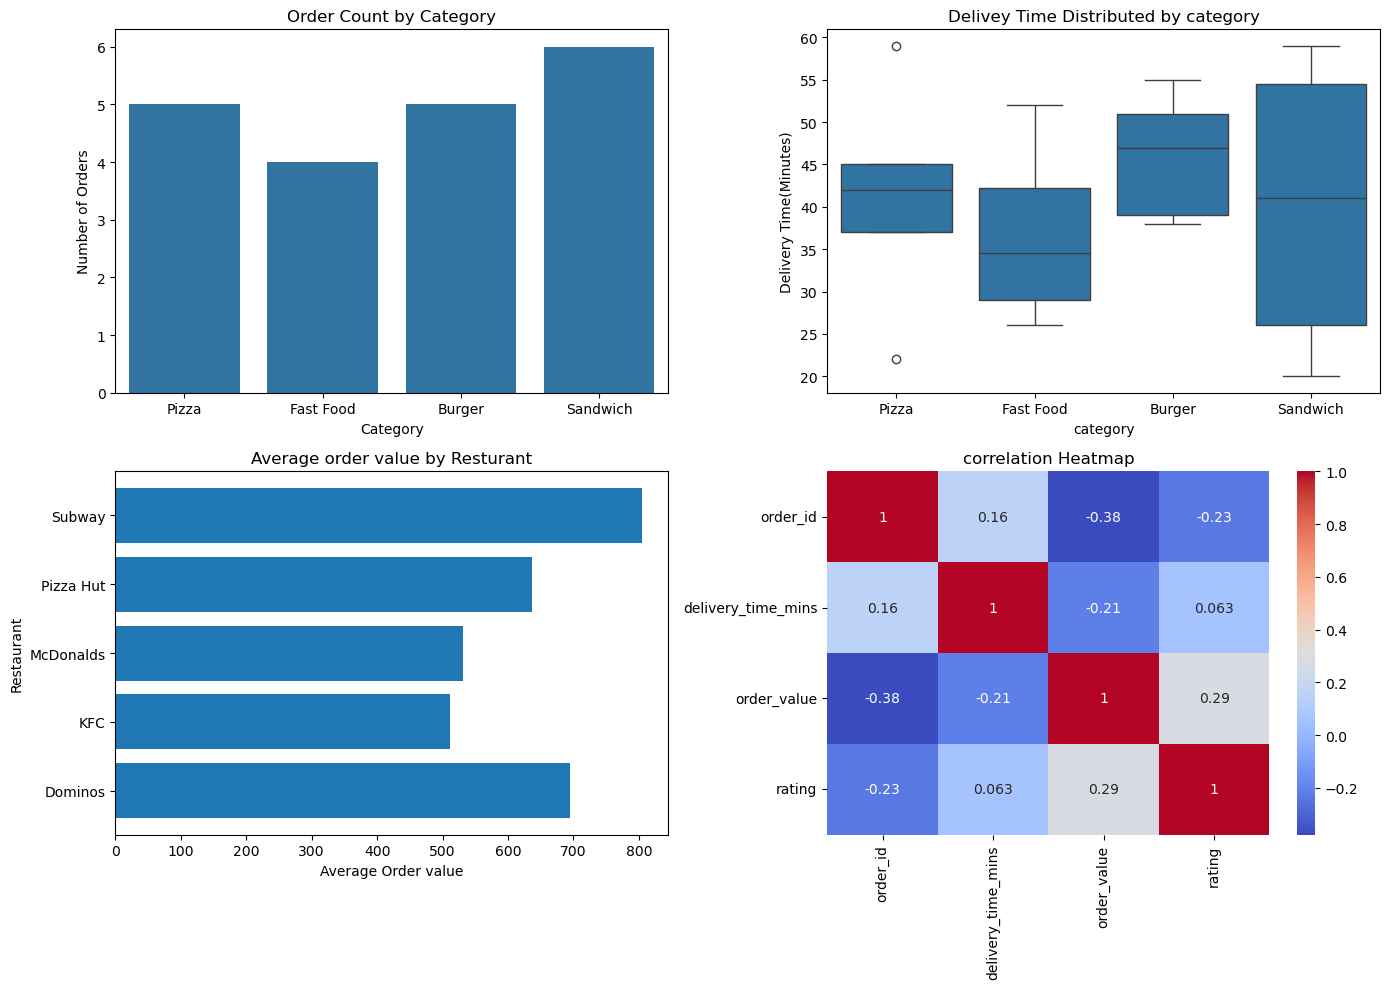

In [321]:
# Create subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# countplot

sns.countplot(
    data=df,
    x="category",
    ax=axes[0,0]
)
axes[0, 0].set_title("Order Count by Category")
axes[0, 0].set_xlabel("Category")
axes[0, 0].set_ylabel("Number of Orders")

# Box Plot
sns.boxplot(
    data=df,
    x="category",
    y="delivery_time_mins",
    ax=axes[0,1]
)
axes[0,1].set_title("Delivey Time Distributed by category")
axes[0,1].set_xlabel("category")
axes[0,1].set_ylabel("Delivery Time(Minutes)")


# Horizontal Bar chart

avg_order=df.groupby("restaurant_name")['order_value'].mean()

axes[1,0].barh(
    avg_order.index,
    avg_order.values
)
axes[1,0].set_title("Average order value by Resturant")
axes[1,0].set_xlabel("Average Order value")
axes[1,0].set_ylabel("Restaurant")

# Heat Map

corr =df.select_dtypes(include=np.number).corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    ax=axes[1,1]
)
axes[1,1].set_title("correlation Heatmap")

plt.tight_layout()

In [323]:
# Task 4



In [327]:
# import pandas as pd
# import sqlite3

In [329]:
# conn = sqlite3.connect("food_delivery.db")
# cursor = conn.cursor()

In [347]:
# cursor.execute("""
# CREATE TABLE IF NOT EXISTS restaurants (
#     restaurant_id INTEGER PRIMARY KEY,
#     name TEXT,
#     category TEXT,
#     city TEXT
# )
# """)

# cursor.execute("""
# CREATE TABLE IF NOT EXISTS orders (
#     order_id INTEGER PRIMARY KEY,
#     restaurant_id INTEGER,
#     order_value REAL,
#     delivery_time_mins REAL,
#     rating REAL,
#     FOREIGN KEY (restaurant_id) REFERENCES restaurants(restaurant_id)
# )
# """)
# restaurants = [
#     (1, "Dominos", "Pizza", "Ahmedabad"),
#     (2, "KFC", "Fast Food", "Ahmedabad"),
#     (3, "McDonalds", "Burger", "Surat"),
#     (4, "Pizza Hut", "Pizza", "Vadodara"),
#     (5, "Subway", "Sandwich", "Rajkot"),
#     (6, "Burger King", "Burger", "Ahmedabad"),
#     (7, "La Pinoz", "Pizza", "Surat"),
#     (8, "Wow Momo", "Momos", "Vadodara")
# ]
# cursor.executemany("""
# INSERT INTO restaurants
# VALUES (?, ?, ?, ?)
# """, restaurants)
# orders = [
#     (101,1,450,30,4.5),
#     (102,2,320,35,4.2),
#     (103,3,580,28,4.8),
#     (104,4,620,40,4.3),
#     (105,5,310,25,4.6),
#     (106,6,480,32,4.1),
#     (107,7,700,38,4.9),
#     (108,8,350,27,4.0),
#     (109,1,550,31,4.7),
#     (110,2,420,36,4.3),
#     (111,3,610,30,4.6),
#     (112,4,690,42,4.8),
#     (113,5,330,26,4.2),
#     (114,6,510,34,4.5),
#     (115,7,750,39,4.9),
#     (116,8,390,28,4.1),
#     (117,1,470,29,4.4),
#     (118,2,440,37,4.2),
#     (119,3,590,31,4.7),
#     (120,4,720,41,4.8),
#     (121,5,360,24,4.3),
#     (122,6,530,35,4.6),
#     (123,7,780,40,5.0),
#     (124,8,410,29,4.2),
#     (125,1,600,33,4.9)
# ]

# cursor.executemany("""
# INSERT INTO orders
# VALUES (?, ?, ?, ?, ?)
# """, orders)

# conn.commit()

# query = """
# SELECT
#     r.restaurant_id,
#     r.name AS restaurant_name,
#     r.category,
#     r.city,
#     COUNT(o.order_id) AS total_orders,
#     SUM(o.order_value) AS total_revenue,
#     ROUND(AVG(o.rating), 2) AS avg_rating
# FROM restaurants r
# JOIN orders o
# ON r.restaurant_id = o.restaurant_id
# GROUP BY r.restaurant_id, r.name, r.category, r.city
# """
# df = pd.read_sql_query(query, conn)
# df["revenue_rank"] = (
#     df["total_revenue"]
#     .rank(ascending=False, method="min")
#     .astype(int)
# )
# df = df.sort_values("revenue_rank")
# print("\nRestaurant Performance Report\n")
# print(df)
# df.to_csv(
#     "restaurant_performance_report.csv",
#     index=False
# )

# print("\nReport exported successfully as 'restaurant_performance_report.csv'")
# conn.close()


IntegrityError: UNIQUE constraint failed: restaurants.restaurant_id